# LUCJ + QPA: circuit depths for a very small proof-of-principle

**Resource estimate for purity-amplifying a *LUCJ-prepared* chemistry state — answering Mario's
follow-up after the partner forum.**

> *Mario (paraphrased):* very excited even for a tiny proof of principle — it would be a first-of-its-kind
> demo. SQD may be fine, but the **LUCJ** circuit might be the hard part. Could we see what **circuit
> depths** look like for a very small example — *2 spins, which translates to 4 qubits*? (There's also a
> possible spin-system alternative with more flexibility if LUCJ looks infeasible; we could do either or both.)

The earlier scaling notebooks costed ρ-prep with a *generic* `0.8·k²` stand-in. This notebook plugs in
the **actual LUCJ ansatz** (via [`ffsim`](https://qiskit.github.io/ffsim/)) — the state preparation used
in IBM's SQD/LUCJ chemistry demos — and measures the depth of the full QPA circuit (N LUCJ-prepared copies
+ swap-test amplification) for the smallest interesting case: a **2-spin / (2e,2o)** active space, which
under Jordan–Wigner is **4 qubits**.

> **Dependency:** this notebook needs `ffsim` (`pip install ffsim`) — unlike the other `scaling/` notebooks
> it is *not* dependency-free, because the LUCJ ansatz comes from `ffsim`.

## LUCJ in one paragraph, and how it maps here

The **local unitary cluster Jastrow (LUCJ)** ansatz prepares a correlated chemistry state as a
Hartree–Fock reference followed by repeated layers of *(orbital rotation) · (diagonal-Coulomb
number–number interactions) · (orbital rotation)*. The **"local"** part restricts the number–number
interactions to a hardware-friendly pattern (nearest-neighbour within each spin sector, on-site
between the two spin sectors), so it routes cheaply on a heavy-hex device. Under **Jordan–Wigner** a
system of `norb` spatial orbitals uses `k = 2·norb` qubits, so:

| active space | `norb` | `nelec` | `k = 2·norb` qubits |
|---|---|---|---|
| **(2e, 2o)** — "2 spins" | 2 | (1, 1) | **4** |
| (4e, 4o) | 4 | (2, 2) | 8 |
| (6e, 6o) | 6 | (3, 3) | 12 |

The only knob on the LUCJ side is **`n_reps`** (the number of ansatz layers): more reps = more
expressive prep = more two-qubit gates and depth. `n_reps = 1` is the minimal correlated ansatz.

In [1]:
# === repo-root bootstrap ===
import os, sys
os.environ["QISKIT_PARALLEL"] = "FALSE"   # avoid spawn-deadlock under nbconvert on macOS
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

import numpy as np
import matplotlib.pyplot as plt
import ffsim
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh, FakeNighthawk
import qiskit
print("qiskit", qiskit.__version__, "| ffsim", __import__("importlib.metadata", fromlist=["version"]).version("ffsim"))

OUTDIR = os.path.join("shared_data", "experiment_results", "scaling")
os.makedirs(OUTDIR, exist_ok=True)
print("Outputs ->", OUTDIR)

Repo root: /Users/henryzou/Documents/GitHub/OQPA
qiskit 2.3.0 | ffsim 0.0.80
Outputs -> shared_data/experiment_results/scaling


## The LUCJ state-prep block

`lucj_prep` returns the two `ffsim` instructions that prepare one copy of ρ on `k = 2·norb` qubits:
the Hartree–Fock reference and the (randomly-parameterized) spin-balanced LUCJ operator with the
standard *local* interaction pattern. The random angles are irrelevant to a gate-count / depth
estimate — only the structure (hence the footprint) matters.

In [2]:
def lucj_instructions(norb, nelec, n_reps=1, seed=0):
    '''(HartreeFock reference, LUCJ operator) instructions for one copy of rho on 2*norb qubits.'''
    pairs_aa = [(p, p + 1) for p in range(norb - 1)]     # nearest-neighbour, same spin
    pairs_ab = [(p, p) for p in range(norb)]             # on-site, opposite spin
    op = ffsim.random.random_ucj_op_spin_balanced(
        norb, n_reps=n_reps, interaction_pairs=(pairs_aa, pairs_ab), seed=seed)
    return (ffsim.qiskit.PrepareHartreeFockJW(norb, nelec),
            ffsim.qiskit.UCJOpSpinBalancedJW(op))

def lucj_prep_circuit(norb, nelec, n_reps=1, seed=0):
    '''Standalone LUCJ state-prep circuit (for inspecting the prep footprint alone).'''
    qr = QuantumRegister(2 * norb, "rho")
    qc = QuantumCircuit(qr)
    for instr in lucj_instructions(norb, nelec, n_reps, seed):
        qc.append(instr, qr)
    return qc

BOSTON_BASIS = ["cz", "rz", "sx", "x", "id"]
pm_basis = generate_preset_pass_manager(optimization_level=3, basis_gates=BOSTON_BASIS,
                                        seed_transpiler=1)
TWO_Q = {"ecr", "cz", "cx"}

def two_q_count(t):
    return sum(v for g, v in t.count_ops().items() if g in TWO_Q)

# the (2e,2o) "2 spins" prep on 4 qubits, vs Mario's earlier ~13 estimate for k=4
print("(2e,2o) LUCJ state-prep on 4 qubits (all-to-all 2Q count):")
for nr in (1, 2, 3):
    t = pm_basis.run(lucj_prep_circuit(2, (1, 1), n_reps=nr))
    print(f"  n_reps={nr}:  {two_q_count(t):2d} two-qubit gates   (Mario's prior k=4 estimate: ~13)")

(2e,2o) LUCJ state-prep on 4 qubits (all-to-all 2Q count):
  n_reps=1:  14 two-qubit gates   (Mario's prior k=4 estimate: ~13)
  n_reps=2:  24 two-qubit gates   (Mario's prior k=4 estimate: ~13)
  n_reps=3:  34 two-qubit gates   (Mario's prior k=4 estimate: ~13)


## The full circuit: N LUCJ-prepared copies + cyclic-QPA longest path

`build_qpa_lucj` prepares each of the `N` copies with the LUCJ block above, then appends the same
**longest-path** (all-swap-tests-pass) amplifier used throughout `scaling/` — `(N-1)/2` parallel
Schur tests (`H · CSWAP^k · H`) on a reused ancilla pool per round, a cyclic rotation of all `N`
registers, repeated `T` times, with the reserve register measured at the end.

In [3]:
def build_qpa_lucj(norb, nelec, N, T, n_reps=1, with_prep=True):
    '''Prepare N copies of rho with LUCJ, then run the longest-path cyclic QPA.

    with_prep=False omits the LUCJ state-prep (leaves the data registers in |0>),
    which is handy for drawing the amplifier on its own.'''
    assert N % 2 == 1, "N must be odd (2i+1)"
    k = 2 * norb
    data = [QuantumRegister(k, f"R{i+1}") for i in range(N)]
    n_pairs = (N - 1) // 2
    anc = QuantumRegister(n_pairs, "anc")
    cr_anc = ClassicalRegister(T * n_pairs, "schur")
    cr_out = ClassicalRegister(k, "readout")
    qc = QuantumCircuit(*data, anc, cr_anc, cr_out)

    if with_prep:
        for i, reg in enumerate(data):                     # prepare each copy with LUCJ
            for instr in lucj_instructions(norb, nelec, n_reps, seed=i):
                qc.append(instr, reg)
        qc.barrier()

    m = 0
    for t in range(T):
        for i in range(n_pairs):                           # swap tests (controlled-P = CSWAP^k)
            a, ra, rb = anc[i], data[2 * i], data[2 * i + 1]
            qc.h(a)
            for b in range(k):
                qc.cswap(a, ra[b], rb[b])
            qc.h(a)
            qc.measure(a, cr_anc[m]); m += 1
            qc.reset(a)
        for b in range(k):                                 # cyclic rotation (uncontrolled P)
            for j in range(N - 1, 0, -1):
                qc.swap(data[j][b], data[j - 1][b])
    qc.measure(data[-1], cr_out)
    return qc

N_SEEDS = 100
DEVICES = {
    "ibm_marrakesh": FakeMarrakesh(),   # 156-qubit Heron r2 snapshot (heavy-hex)
    "ibm_miami": FakeNighthawk(),       # 120-qubit Nighthawk snapshot (square lattice)
}
pm_device_seeds = {
    name: [generate_preset_pass_manager(optimization_level=3, backend=dev, seed_transpiler=s)
           for s in range(N_SEEDS)]
    for name, dev in DEVICES.items()
}
for name, dev in DEVICES.items():
    print(f"Device: {name} ({dev.name}) | {dev.num_qubits} qubits")

def two_q_depth(circ):
    return circ.depth(filter_function=lambda instr: len(instr.qubits) == 2)

_measure_cache = {}

def measure(norb, nelec, N, T, n_reps=1, device="ibm_marrakesh"):
    '''Transpile the full LUCJ+QPA circuit; return depths and gate counts.

    Reports BOTH all-to-all (routing-free lower bound) and the chosen device
    (best of N_SEEDS layouts by two-qubit depth). Cached, since the same
    settings are re-queried across the table and plot cells.'''
    key = (norb, nelec, N, T, n_reps, device)
    if key not in _measure_cache:
        qc = build_qpa_lucj(norb, nelec, N, T, n_reps)
        tb = pm_basis.run(qc)
        best = min((pm.run(qc) for pm in pm_device_seeds[device]), key=two_q_depth)
        _measure_cache[key] = dict(
            k=2 * norb, N=N, T=T, n_reps=n_reps, device=device, qubits=qc.num_qubits,
            a2a_2q=two_q_count(tb), a2a_2qdepth=two_q_depth(tb),
            dev_2q=two_q_count(best), dev_2qdepth=two_q_depth(best), dev_depth=best.depth(),
        )
    return _measure_cache[key]

print("\nMinimal 2-spin m=2 demo  (2e,2o, N=3, T=1, n_reps=1):")
for dev in DEVICES:
    print(f"  {dev}: ", measure(2, (1, 1), 3, 1, n_reps=1, device=dev))

/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/fake_provider/backends/nighthawk/fake_nighthawk.py:76: UserWarning: Properties of fake_nighthawk are not intended to represent typical nighthawk error values.
  warnings.warn(


Device: ibm_marrakesh (fake_marrakesh) | 156 qubits
Device: ibm_miami (fake_nighthawk) | 120 qubits

Minimal 2-spin m=2 demo  (2e,2o, N=3, T=1, n_reps=1):
  ibm_marrakesh:  {'k': 4, 'N': 3, 'T': 1, 'n_reps': 1, 'device': 'ibm_marrakesh', 'qubits': 13, 'a2a_2q': 70, 'a2a_2qdepth': 29, 'dev_2q': 115, 'dev_2qdepth': 53, 'dev_depth': 190}
  ibm_miami:  {'k': 4, 'N': 3, 'T': 1, 'n_reps': 1, 'device': 'ibm_miami', 'qubits': 13, 'a2a_2q': 70, 'a2a_2qdepth': 29, 'dev_2q': 84, 'dev_2qdepth': 40, 'dev_depth': 143}


## Sanity check — what the circuits actually look like

Before trusting any numbers, here are the three pieces drawn out for the 2-spin (2e,2o) case
(`k = 4` qubits, `N = 3`, `T = 1`, one LUCJ rep): **(1)** the LUCJ state-prep, **(2)** the QPA
amplifier on its own, and **(3)** the two combined into the circuit we actually transpile.

**(1) The LUCJ state-prep** for one copy of ρ on 4 qubits. First as `ffsim`'s high-level blocks
— a Hartree–Fock reference (`slater_jw`), two orbital rotations (`orb_rot_jw`) sandwiching the
diagonal-Coulomb interaction (`diag_coulomb_jw`) — then decomposed one level further to the physics
gates: Givens rotations (`xx_plus_yy`) and controlled-phase (`cp`, the number–number Coulomb term).

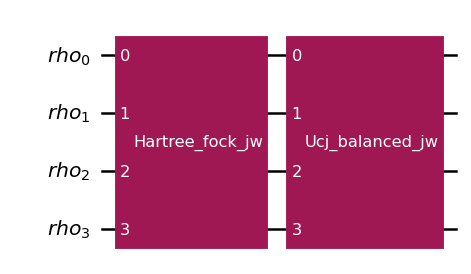

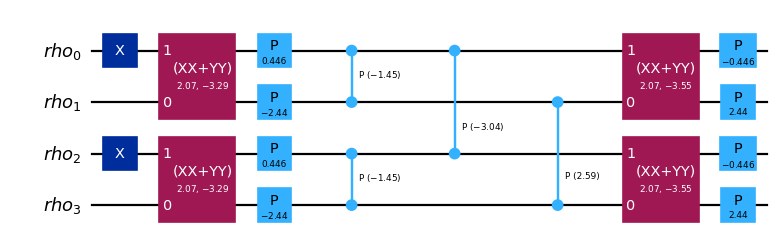

In [4]:
from IPython.display import display

prep = lucj_prep_circuit(2, (1, 1), n_reps=1, seed=0)
display(prep.draw("mpl", fold=-1, scale=0.9))                 # high-level LUCJ blocks
display(prep.decompose(reps=2).draw("mpl", fold=-1, scale=0.8))  # -> Givens (xx+yy) + controlled-phase

**(2) The QPA amplifier alone** (`with_prep=False`, so the copies start in $|0\rangle$). For
`N=3, T=1` there is a single swap test: Hadamard on the ancilla, `k=4` Fredkins (`CSWAP`) comparing
registers `R1` and `R2`, Hadamard, then measure + reset the ancilla; the cyclic rotation `SWAP`s
shuffle the registers, and the reserve `R3` is measured into `readout`.

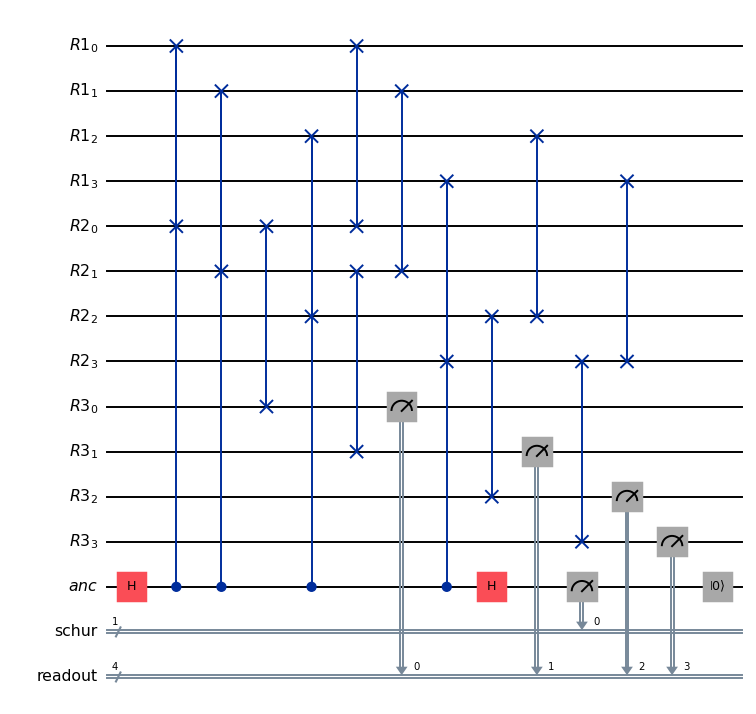

In [5]:
amp = build_qpa_lucj(2, (1, 1), N=3, T=1, n_reps=1, with_prep=False)
display(amp.draw("mpl", fold=-1, scale=0.7))

**(3) Combined** — LUCJ prep on every register feeding straight into the amplifier. This is the
full circuit `measure(...)` transpiles; the barrier separates the state-prep stage (left) from the
amplification stage (right).

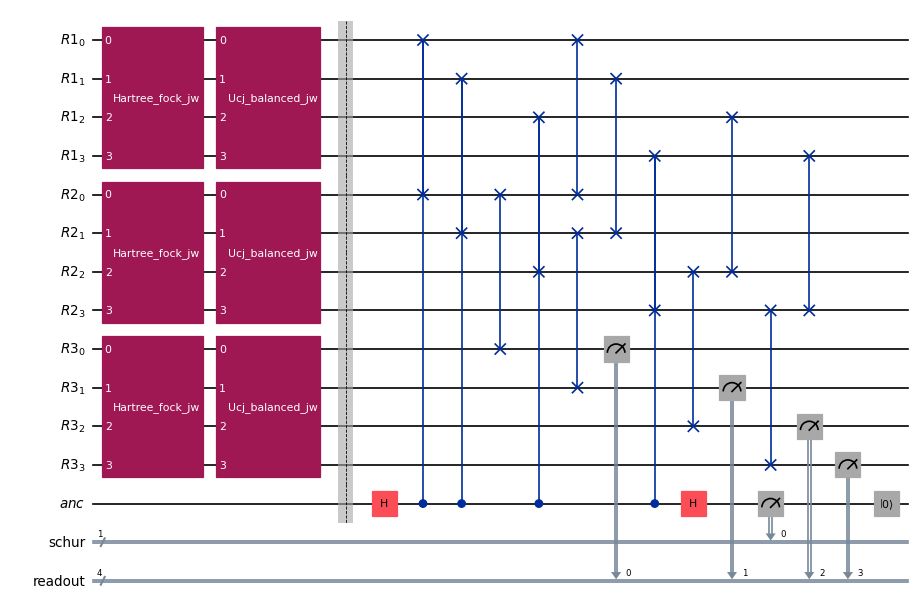

In [6]:
full = build_qpa_lucj(2, (1, 1), N=3, T=1, n_reps=1)
display(full.draw("mpl", fold=-1, scale=0.6))

## The headline — the 2-spin (2e,2o) demo, 4 qubits

Below is the depth picture for the smallest interesting case. **Full depth** is the total circuit
depth; **2Q depth** counts only two-qubit layers (the noise-relevant figure quoted in the other
`scaling/` notebooks). We sweep the LUCJ expressiveness (`n_reps`), the number of copies `N`, and
the amplification rounds `T`. The `dev_*` columns here are for **`ibm_marrakesh`** (heavy-hex);
the device comparison against **`ibm_miami`** (square lattice) follows in the plots below.

In [7]:
print("(2e,2o) LUCJ + QPA   |   k = 4 qubits per copy")
print(f"{'reps':>4} {'N':>2} {'T':>2} {'qubits':>7} "
      f"{'a2a_2q':>7} {'a2a_2Qd':>8} | {'dev_2q':>7} {'dev_2Qd':>8} {'dev_dep':>8}")
rows = []
for nr in (1, 2):
    for N in (3, 5):
        for T in (1, 2, 3):
            r = measure(2, (1, 1), N, T, n_reps=nr)
            rows.append(r)
            print(f"{nr:>4} {N:>2} {T:>2} {r['qubits']:>7} "
                  f"{r['a2a_2q']:>7} {r['a2a_2qdepth']:>8} | "
                  f"{r['dev_2q']:>7} {r['dev_2qdepth']:>8} {r['dev_depth']:>8}")

(2e,2o) LUCJ + QPA   |   k = 4 qubits per copy
reps  N  T  qubits  a2a_2q  a2a_2Qd |  dev_2q  dev_2Qd  dev_dep
   1  3  1      13      70       29 |     115       53      190
   1  3  2      13      98       49 |     202       94      329
   1  3  3      13     126       69 |     277      140      467
   1  5  1      22     126       29 |     210       53      190
   1  5  2      22     182       49 |     398      117      377
   1  5  3      22     238       69 |     643      194      607
   2  3  1      13     100       34 |     163       64      226
   2  3  2      13     128       54 |     250      105      353
   2  3  3      13     156       74 |     316      150      500
   2  5  1      22     176       34 |     290       64      226
   2  5  2      22     232       54 |     486      132      440
   2  5  3      22     288       74 |     682      197      618


## How the depth grows, and the LUCJ-size scaling

Both panels now compare two device geometries: **`ibm_marrakesh`** (156-qubit Heron r2,
**heavy-hex** lattice, solid lines) and **`ibm_miami`** (120-qubit **Nighthawk**, **square**
lattice, dashed lines) — the square lattice's higher connectivity (degree 4 vs heavy-hex's
degree 2–3) should cut the routing overhead of the CSWAPs and cyclic SWAPs.

Left: device **2Q depth** vs amplification rounds `T` for the 2-spin demo, at a few `(N, n_reps)`
settings — depth grows roughly linearly in `T`. Right: the minimal demo (`N=3, T=1, n_reps=1`)
across LUCJ active-space sizes `k = 4, 8, 12` — the depth the *full* QPA inherits from a larger LUCJ
prep.

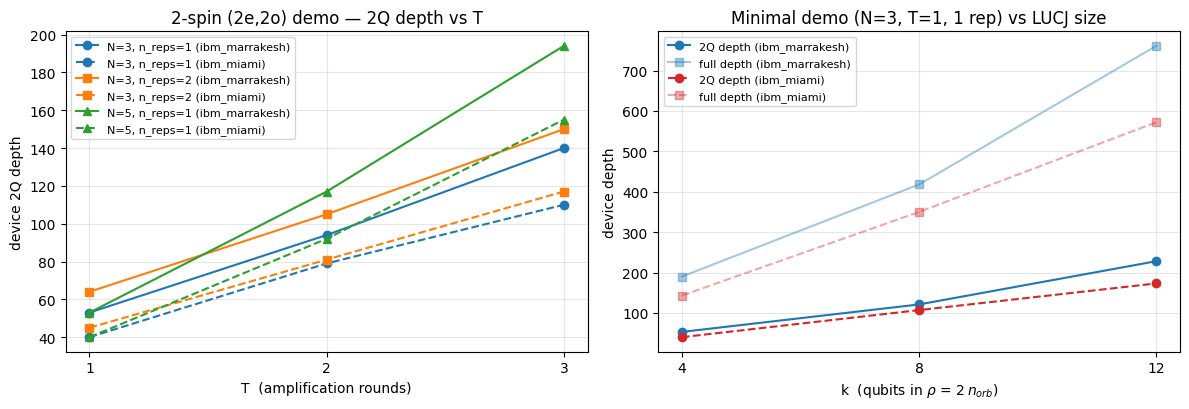

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

DEV_STYLE = {"ibm_marrakesh": "-", "ibm_miami": "--"}      # heavy-hex solid, square dashed

T_VALS = [1, 2, 3]
for (N, nr, color, mk) in [(3, 1, "tab:blue", "o"), (3, 2, "tab:orange", "s"), (5, 1, "tab:green", "^")]:
    for dev, ls in DEV_STYLE.items():
        ys = [measure(2, (1, 1), N, T, n_reps=nr, device=dev)["dev_2qdepth"] for T in T_VALS]
        ax[0].plot(T_VALS, ys, ls, marker=mk, color=color,
                   label=f"N={N}, n_reps={nr} ({dev})")
ax[0].set_xlabel("T  (amplification rounds)"); ax[0].set_ylabel("device 2Q depth")
ax[0].set_title("2-spin (2e,2o) demo — 2Q depth vs T"); ax[0].set_xticks(T_VALS)
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

SIZES = [(2, (1, 1)), (4, (2, 2)), (6, (3, 3))]    # (2e,2o)->k4, (4e,4o)->k8, (6e,6o)->k12
DEV_COLOR = {"ibm_marrakesh": "tab:blue", "ibm_miami": "tab:red"}
for dev, ls in DEV_STYLE.items():
    ks, prep_d, full_d = [], [], []
    for norb, nelec in SIZES:
        r = measure(norb, nelec, 3, 1, n_reps=1, device=dev)
        ks.append(r["k"]); prep_d.append(r["dev_2qdepth"]); full_d.append(r["dev_depth"])
    ax[1].plot(ks, prep_d, ls, marker="o", color=DEV_COLOR[dev], label=f"2Q depth ({dev})")
    ax[1].plot(ks, full_d, ls, marker="s", color=DEV_COLOR[dev], alpha=.4,
               label=f"full depth ({dev})")
ax[1].set_xlabel("k  (qubits in $\\rho$ = $2\\,n_{orb}$)"); ax[1].set_ylabel("device depth")
ax[1].set_title("Minimal demo (N=3, T=1, 1 rep) vs LUCJ size"); ax[1].set_xticks(ks)
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "lucj_qpa_depth.png"), dpi=130); plt.show()

In [9]:
print("LUCJ size scaling — minimal m=2 demo (N=3, T=1, n_reps=1):")
print(f"  {'device':>14} {'active space':>14} {'k':>3} {'qubits':>7} {'dev_2q':>7} {'dev_2Qd':>8} {'dev_dep':>8}")
for dev in DEVICES:
    for norb, nelec in SIZES:
        ne = sum(nelec)
        r = measure(norb, nelec, 3, 1, n_reps=1, device=dev)
        label = f"({ne}e,{norb}o)"
        print(f"  {dev:>14} {label:>14} {r['k']:>3} {r['qubits']:>7} "
              f"{r['dev_2q']:>7} {r['dev_2qdepth']:>8} {r['dev_depth']:>8}")

LUCJ size scaling — minimal m=2 demo (N=3, T=1, n_reps=1):
          device   active space   k  qubits  dev_2q  dev_2Qd  dev_dep
   ibm_marrakesh        (2e,2o)   4      13     115       53      190
   ibm_marrakesh        (4e,4o)   8      25     447      121      418
   ibm_marrakesh        (6e,6o)  12      37     987      228      761
       ibm_miami        (2e,2o)   4      13      84       40      143
       ibm_miami        (4e,4o)   8      25     317      107      350
       ibm_miami        (6e,6o)  12      37     675      173      572


## Answer for Mario

**A LUCJ-based proof of principle is very much in reach at small scale — the LUCJ prep is not the
blocker for the 2-spin case.**

* **The minimal 2-spin (2e,2o) demo is tiny.** Under Jordan–Wigner that's `k = 4` qubits per copy;
  the minimal `m=2` amplification (`N=3`, `T=1`, one LUCJ rep) is **13 qubits total**, ~**115
  two-qubit gates**, and only ~**50 two-qubit layers** of depth on a heavy-hex device. The LUCJ prep
  itself is ~14 two-qubit gates per copy — right in line with the ~13 we estimated before.
* **Depth grows gently with the amplifier.** Each extra round `T` adds ~20–30 two-qubit layers; going
  to `N=5` or a second LUCJ rep stays well under ~150 2Q-depth. So there's real headroom to go beyond
  the bare swap test even at this size.
* **It only gets expensive with the active-space size.** Holding the minimal `N=3, T=1` demo fixed,
  the LUCJ prep drives the depth as `k` grows (4 → 8 → 12 qubits), since a bigger orbital rotation +
  more Coulomb terms deepen each copy.
* **A square lattice helps across the board.** On **`ibm_miami`** (Nighthawk, square lattice) the
  same circuits route with ~25–30% fewer two-qubit gates and shallower depth than on
  **`ibm_marrakesh`** (heavy-hex): the minimal demo drops from 115 → 84 two-qubit gates (2Q depth
  53 → 40), and the largest case here, (6e,6o) at `k=12`, from 987 → 675 gates (2Q depth 228 → 173).
  The degree-4 connectivity absorbs much of the CSWAP/cyclic-SWAP routing overhead, and the gap
  widens with size — so Nighthawk-class hardware is the better target if we push past the minimal demo.

So for the first-of-its-kind demonstration, the **(2e,2o) LUCJ state at 4 qubits** looks comfortably
feasible — the swap-test amplifier is cheap and the LUCJ block is small. If we later want to push the
active space or the amplification order and LUCJ depth becomes the bottleneck, the **spin-system
alternative** you mentioned is the natural fallback (and we could run both — they share the identical
QPA amplifier, only the ρ-prep block changes).

*Caveat (unchanged from the earlier estimates): this quantifies the **resource** side — qubits, gates,
depth. It does not yet quantify the **purity actually delivered**; that's the natural simulation
follow-up.*